# Continual Reinforcement Learning for Non-Stationary Cognitive Radios
Complete code for the 7-task diurnal traffic simulation.


### 1. Installations and Imports

In [ ]:
# Install required dependencies
!pip install -q torch==2.7.1 numpy==2.2.6 pandas==2.2.3 river==0.26.0 matplotlib==3.10.3 seaborn==0.13.2
print("Dependencies installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.1 MB/s eta 0:00:00


In [ ]:
# Import required libraries
import copy
import logging
import os
import pickle
import queue
import random
import shutil
import threading
from collections import deque
import numpy as np
import pandas as pd
import river
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print("Imports loaded successfully.")

PyTorch: 2.10.0+cu128
NumPy: 2.0.2
Pandas: 2.3.3
River: 0.26.0
CUDA available: True


### 2. Helper Utilities


In [ ]:
# Contains helpers for logging, parameter parsing, atomic checkpoint save/load, and result plotting.

def setup_logger():
    """Sets up a basic console logger."""
    logger = logging.getLogger("CRN_Continual")
    logger.setLevel(logging.INFO)
    
    if not logger.handlers:
        ch = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        
    return logger

def atomic_save(obj, filepath, is_torch=True):
    """Saves an object to a .tmp file first, then renames it to prevent corruption."""
    tmp_path = filepath + ".tmp"
    if is_torch:
        torch.save(obj, tmp_path)
    else:
        with open(tmp_path, 'wb') as f:
            pickle.dump(obj, f)
            
    # Atomic rename (POSIX) or overwrite (Windows)
    shutil.move(tmp_path, filepath)

def save_checkpoint(task_id, policy_net, target_net, fisher_dict, theta_star_dict, episodic_memory, metrics_df, save_dir="checkpoints"):
    """
    Saves all critical components at a task boundary exactly as specified in workflow.md.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Policy & Target Nets
    nets = {
        'policy': policy_net.state_dict(),
        'target': target_net.state_dict()
    }
    atomic_save(nets, os.path.join(save_dir, f"task_{task_id}_policy.pt"), is_torch=True)
    
    # 2. Fisher Dict
    if fisher_dict:
        atomic_save(fisher_dict, os.path.join(save_dir, f"task_{task_id}_fisher.pkl"), is_torch=True)
        
    # 3. Theta Star Snapshot
    if theta_star_dict:
        atomic_save(theta_star_dict, os.path.join(save_dir, f"task_{task_id}_theta_star.pkl"), is_torch=True)
        
    # 4. Episodic Memory
    if episodic_memory and len(episodic_memory) > 0:
        atomic_save(episodic_memory.memory, os.path.join(save_dir, f"task_{task_id}_episodic.pkl"), is_torch=False)
        
    # 5. Metrics DataFrame
    if metrics_df is not None and not metrics_df.empty:
        tmp_csv = os.path.join(save_dir, "metrics.csv.tmp")
        metrics_df.to_csv(tmp_csv, index=False)
        shutil.move(tmp_csv, os.path.join(save_dir, "metrics.csv"))

def save_rollback_checkpoint(policy_net, filepath):
    """Saves a temporary checkpoint used for ADWIN delay rollback."""
    atomic_save(policy_net.state_dict(), filepath, is_torch=True)

def load_rollback_checkpoint(policy_net, filepath):
    """Loads a temporary checkpoint to execute an ADWIN rollback."""
    if os.path.exists(filepath):
        policy_net.load_state_dict(torch.load(filepath))
        return True
    return False

print("Utility functions defined successfully.")

### 3. Environment Generation


In [ ]:
# Contains simulated non-stationary Cognitive Radio environments (Tasks T1-T7).

class CRNEnv:
    """Base Cognitive Radio Network Environment."""
    def __init__(self, num_channels=8, history_length=5, max_steps=1000):
        self.num_channels = num_channels
        self.history_length = history_length
        self.max_steps = max_steps
        
        self.state_dim = self.num_channels * 2 * self.history_length
        self.action_space = self.num_channels + 1
        self.idle_action = self.num_channels
        
        self.R_success = 1.0
        self.R_collision = 1.0
        self.R_idle = 0.05
        
        # PU Activity Probabilities (to be defined by subclasses)
        self.pu_activity_probs = np.zeros(self.num_channels)
        
        # History buffers: list of deques for each channel
        self.snr_history = [deque(maxlen=self.history_length) for _ in range(self.num_channels)]
        self.occ_history = [deque(maxlen=self.history_length) for _ in range(self.num_channels)]
        
        self.current_step = 0

    def _set_probs(self, seed, base_low, base_high):
        """Helper to generate distinct but consistent probabilities per task."""
        rng = np.random.RandomState(seed)
        self.pu_activity_probs = rng.uniform(base_low, base_high, self.num_channels)
        
        # Guarantee at least one "optimal" channel that is relatively more free
        optimal_channel = rng.randint(0, self.num_channels)
        self.pu_activity_probs[optimal_channel] = max(0.01, base_low * 0.5)

    def reset(self):
        self.current_step = 0
        # Clear histories
        for c in range(self.num_channels):
            self.snr_history[c].clear()
            self.occ_history[c].clear()
            
        # Initialize history with random observations
        for _ in range(self.history_length):
            self._generate_observation()
            
        return self.get_state()

    def _generate_observation(self):
        """Generates a single timestep observation for all channels and appends to history."""
        for c in range(self.num_channels):
            is_busy = np.random.rand() < self.pu_activity_probs[c]
            
            # Simulate SNR (normalized 0 to 1)
            if is_busy:
                snr = np.random.uniform(0.5, 1.0) # High SNR if PU is transmitting
                occ = 1
            else:
                snr = np.random.uniform(0.0, 0.2) # Low SNR (noise) if idle
                occ = 0
                
            self.snr_history[c].append(snr)
            self.occ_history[c].append(occ)

    def step(self, action):
        """
        Executes action, computes reward, and transitions to next state.
        Action N is idle. Actions 0 to N-1 are channels.
        """
        # The current true state of the channels is the last generated observation
        current_occ = [self.occ_history[c][-1] for c in range(self.num_channels)]
        
        reward = 0.0
        if action == self.idle_action:
            reward = -self.R_idle
        elif 0 <= action < self.num_channels:
            if current_occ[action] == 1:
                reward = -self.R_collision
            else:
                reward = self.R_success
        else:
            raise ValueError(f"Invalid action {action}")
            
        # Transition environment to the next timestep
        self._generate_observation()
        self.current_step += 1
        
        done = self.current_step >= self.max_steps
        
        return self.get_state(), reward, done, {}

    def get_state(self):
        """Returns the flattened state vector of size N * 2M."""
        state = []
        for c in range(self.num_channels):
            state.extend(self.snr_history[c])
            state.extend(self.occ_history[c])
        return np.array(state, dtype=np.float32)


# --- 7 Task Environments ---

class Task1Env(CRNEnv):
    """T1: 6:00 AM | Early commute ramp-up | Low-Medium"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=42, base_low=0.2, base_high=0.4)

class Task2Env(CRNEnv):
    """T2: 9:00 AM | Peak commute traffic | High"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=43, base_low=0.6, base_high=0.9)

class Task3Env(CRNEnv):
    """T3: 12:00 PM | Midday office traffic | Medium"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=44, base_low=0.4, base_high=0.6)

class Task4Env(CRNEnv):
    """T4: 2:00 PM | Sparse IoT sensor bursts | Low"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=45, base_low=0.05, base_high=0.2)

class Task5Env(CRNEnv):
    """T5: 5:00 PM | Evening commute | High"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=46, base_low=0.65, base_high=0.85)

class Task6Env(CRNEnv):
    """T6: 8:00 PM | Heavy video streaming | Very High"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=47, base_low=0.8, base_high=0.95)

class Task7Env(CRNEnv):
    """T7: 11:00 PM | Night-time low activity | Very Low"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._set_probs(seed=48, base_low=0.01, base_high=0.1)

print("Cognitive radio environments defined successfully.")

### 4. Agents Creation


In [ ]:
# Contains DQN Model and Boltzmann Action Selection logic.

class DQN(nn.Module):
    """Standard 3-layer Feedforward Deep Q-Network."""
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQNAgent:
    """Agent that manages the DQN, target network, and Boltzmann exploration."""
    def __init__(self, input_dim, output_dim, lr=1e-3, gamma=0.99, device='cpu'):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.gamma = gamma
        self.device = device
        
        # Initialize Networks
        self.policy_net = DQN(input_dim, output_dim).to(self.device)
        self.target_net = DQN(input_dim, output_dim).to(self.device)
        self.update_target_network()
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        
        # Boltzmann Temperature Parameters
        self.tau0 = 2.0
        self.tau_min = 0.1
        self.d = 1e-6
        self.tau = self.tau0
        self.task_step_counter = 0

    def update_target_network(self):
        """Hard copies the policy network weights to the target network."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def reset_temperature(self):
        """Resets the Boltzmann temperature for a new task."""
        self.tau = self.tau0
        self.task_step_counter = 0

    def get_action(self, state, evaluate=False):
        """
        Selects an action using the Boltzmann (Softmax) policy.
        If evaluate=True, selects the greedy action.
        """
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32).to(self.device)
        
        # Ensure batch dimension
        if state.dim() == 1:
            state = state.unsqueeze(0)
            
        with torch.no_grad():
            q_values = self.policy_net(state)
            
        if evaluate:
            # Greedy action for evaluation
            action = torch.argmax(q_values, dim=1).item()
        else:
            # Boltzmann exploration
            # Numerically stable softmax
            q_scaled = q_values / self.tau
            probs = F.softmax(q_scaled, dim=1).cpu().numpy()[0]
            
            # Sample action according to probabilities
            action = np.random.choice(self.output_dim, p=probs)
            
            # Decay temperature
            self.task_step_counter += 1
            self.tau = max(self.tau_min, self.tau0 * np.exp(-self.d * self.task_step_counter))
            
        return action

print("DQN agent components defined successfully.")

### 5. Memory Classes


In [ ]:
# Contains ReplayBuffer and EpisodicMemory classes.

class ReplayBuffer:
    """Standard i.i.d. Experience Replay Buffer for DQN."""
    
    def __init__(self, capacity=100000):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        """Saves a transition to the buffer."""
        self.buffer.append({
            'state': state,
            'action': action,
            'reward': reward,
            'next_state': next_state,
            'done': done
        })
        
    def sample(self, batch_size):
        """Samples a random i.i.d. minibatch."""
        batch = random.sample(self.buffer, batch_size)
        return self._format_batch(batch)

    def _format_batch(self, batch):
        """Helper to convert a list of dicts to PyTorch tensors."""
        states = torch.tensor(np.array([b['state'] for b in batch]), dtype=torch.float32)
        actions = torch.tensor([b['action'] for b in batch], dtype=torch.long)
        rewards = torch.tensor([b['reward'] for b in batch], dtype=torch.float32)
        next_states = torch.tensor(np.array([b['next_state'] for b in batch]), dtype=torch.float32)
        dones = torch.tensor([b['done'] for b in batch], dtype=torch.float32)
        return states, actions, rewards, next_states, dones

    def get_top_k_transitions(self, k, policy_net, target_net, gamma, device, batch_size=512):
        """
        Computes true TD-errors for all transitions in the buffer at the exact moment
        of a task boundary. Returns the Top-K most 'surprising' transitions.
        """
        if len(self.buffer) == 0:
            return []
            
        policy_net.eval()
        td_errors = []
        
        # Process in batches to prevent GPU OOM on large buffers
        buffer_list = list(self.buffer)
        for i in range(0, len(buffer_list), batch_size):
            batch = buffer_list[i:i+batch_size]
            states, actions, rewards, next_states, dones = self._format_batch(batch)
            
            states = states.to(device)
            actions = actions.to(device)
            rewards = rewards.to(device)
            next_states = next_states.to(device)
            dones = dones.to(device)
            
            with torch.no_grad():
                # Current Q values
                q_values = policy_net(states)
                q_expected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
                
                # Target Q values
                q_next = target_net(next_states).max(1)[0]
                q_targets = rewards + gamma * q_next * (1 - dones)
                
                # Absolute TD-error
                errors = torch.abs(q_expected - q_targets).cpu().numpy()
                td_errors.extend(errors)
                
        policy_net.train()
        
        # Pair transitions with their computed td_error and sort descending
        scored_transitions = list(zip(buffer_list, td_errors))
        scored_transitions.sort(key=lambda x: x[1], reverse=True)
        
        # Strip the score and return just the transition dicts
        top_k = [x[0] for x in scored_transitions[:k]]
        return top_k
        
    def flush(self):
        """Clears the buffer to prevent task contamination."""
        self.buffer.clear()
        
    def __len__(self):
        return len(self.buffer)


class EpisodicMemory:
    """
    Permanent memory for Continual Learning. 
    Stores highly informative transitions from past tasks to augment EWC.
    """
    
    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.memory = []
        
    def add_transitions(self, transitions):
        """
        Appends new transitions. If capacity is exceeded, evicts the oldest 10%.
        Because appending happens sequentially by task, the oldest tasks are at the front (FIFO).
        """
        self.memory.extend(transitions)
        
        if len(self.memory) > self.capacity:
            # Evict oldest 10%
            evict_count = int(self.capacity * 0.10)
            excess = len(self.memory) - self.capacity
            remove_count = max(evict_count, excess)
            
            # Slicing from remove_count drops the oldest items
            self.memory = self.memory[remove_count:]
            
    def sample(self, batch_size):
        """Samples a random i.i.d. minibatch from the episodic memory."""
        if len(self.memory) < batch_size:
            batch = self.memory
        else:
            batch = random.sample(self.memory, batch_size)
            
        states = torch.tensor(np.array([b['state'] for b in batch]), dtype=torch.float32)
        actions = torch.tensor([b['action'] for b in batch], dtype=torch.long)
        rewards = torch.tensor([b['reward'] for b in batch], dtype=torch.float32)
        next_states = torch.tensor(np.array([b['next_state'] for b in batch]), dtype=torch.float32)
        dones = torch.tensor([b['done'] for b in batch], dtype=torch.float32)
        
        return states, actions, rewards, next_states, dones
        
    def __len__(self):
        return len(self.memory)

print("Replay and episodic memory classes defined successfully.")

### 6. Elastic Weight Consolidation


In [ ]:
# Contains EWC penalty application, adaptive lambda scheduler, and FIM loss calculations.

class EWC:
    """Manages Elastic Weight Consolidation (EWC) penalties for Continual Learning."""
    
    def __init__(self, policy_net, lambda_max=5.0, beta=10.0, window_size=500):
        self.policy_net = policy_net
        self.lambda_max = lambda_max
        self.beta = beta
        self.window_size = window_size
        
        # Stores (fisher_dict, theta_star_dict) for all completed tasks
        self.past_tasks = [] 
        
        # Rolling window of absolute TD-errors for the adaptive lambda scheduler
        self.td_error_window = deque(maxlen=self.window_size)

    def update_task_penalty(self, fisher_dict, theta_star_dict):
        """
        Called when the async MEC server returns the FIM and theta* for a completed task.
        Moves the tensors to the correct device and stores them for loss computation.
        """
        device = next(self.policy_net.parameters()).device
        
        # Move cached parameters to the active device (usually GPU if available)
        f_dict = {name: f.to(device) for name, f in fisher_dict.items()}
        t_dict = {name: t.to(device) for name, t in theta_star_dict.items()}
        
        self.past_tasks.append((f_dict, t_dict))

    def update_td_error(self, td_error):
        """Appends the latest absolute TD-error to the rolling window."""
        self.td_error_window.append(float(abs(td_error)))

    def reset_td_window(self):
        """Clears the TD-error window at task boundaries."""
        self.td_error_window.clear()

    def get_adaptive_lambda(self):
        """
        Calculates the dynamic penalty coefficient lambda_t based on TD-loss variance.
        Formula: lambda_t = lambda_max / (1 + beta * Var[delta])
        """
        if len(self.td_error_window) < 2:
            return self.lambda_max
            
        variance = np.var(self.td_error_window)
        lambda_t = self.lambda_max / (1.0 + self.beta * variance)
        
        return lambda_t

    def compute_ewc_loss(self):
        """
        Computes the EWC quadratic penalty term to be added to the DQN loss.
        Iterates over all stored past tasks to protect their critical weights.
        """
        device = next(self.policy_net.parameters()).device
        if not self.past_tasks:
            return torch.tensor(0.0, device=device)
            
        lambda_t = self.get_adaptive_lambda()
        ewc_loss = torch.tensor(0.0, device=device)
        
        # Sum the penalty over all parameters for all past tasks
        for fisher_dict, theta_star_dict in self.past_tasks:
            for name, param in self.policy_net.named_parameters():
                if name in fisher_dict and name in theta_star_dict:
                    fisher = fisher_dict[name]
                    theta_star = theta_star_dict[name]
                    
                    # (lambda_t / 2) * F_i * (theta_i - theta_star_i)^2
                    penalty = (fisher * (param - theta_star) ** 2).sum()
                    ewc_loss += penalty
                    
        return (lambda_t / 2.0) * ewc_loss

print("EWC components defined successfully.")

### 7. Change Point Detection


In [ ]:
# Contains ADWIN Change-Point Detection logic.

try:
    from river.drift import ADWIN
except ImportError:
    raise ImportError("The 'river' library is required for ADWIN. Please run: pip install river")

class ChangePointDetector:
    """
    Wraps the ADWIN algorithm to detect task boundaries 
    from the streaming TD-error signal.
    """
    def __init__(self, delta=0.002):
        """
        delta: The confidence parameter for ADWIN. 
               Lower delta means fewer false alarms but slower detection.
        """
        self.delta = delta
        self.adwin = ADWIN(delta=self.delta)
        self.step_counter = 0
        
    def update(self, td_error):
        """
        Feeds a new absolute TD-error into ADWIN.
        
        Returns:
            bool: True if a task boundary (concept drift) is detected.
            int: The exact step index where the boundary occurred (t*).
        """
        self.step_counter += 1
        
        # ADWIN expects scalar numeric data
        self.adwin.update(float(td_error))
        
        if self.adwin.drift_detected:
            # ADWIN's 'width' property represents the number of samples in the 
            # *new* concept window. Therefore, the true boundary started 'width' steps ago.
            boundary_index = max(0, self.step_counter - self.adwin.width)
            return True, boundary_index
            
        return False, None
        
    def reset(self, reset_step_counter=False):
        """
        Resets the ADWIN window after a boundary is handled.
        Optionally resets the global step counter if training is fully restarting.
        """
        self.adwin = ADWIN(delta=self.delta)
        if reset_step_counter:
            self.step_counter = 0

print("Change-point detector defined successfully.")

### 8. MEC Server


In [ ]:
# Contains simulated background thread MEC server for async FIM calculations.

class MECServer:
    """
    Simulates a Mobile Edge Computing (MEC) server running in the background.
    It accepts a frozen snapshot of the policy network and a replay subset,
    computes the Fisher Information Matrix (FIM), and returns it asynchronously.
    """
    def __init__(self, device='cpu'):
        self.device = device
        self.request_queue = queue.Queue()
        self.result_queue = queue.Queue()
        self._stop_event = threading.Event()
        
        # Start the background worker thread
        self.worker_thread = threading.Thread(target=self._worker_loop, daemon=True)
        
    def start(self):
        """Starts the MEC server background thread."""
        self.worker_thread.start()
        
    def stop(self):
        """Signals the thread to stop and cleans up."""
        self._stop_event.set()
        # Push a dummy task to unblock the queue if it's waiting
        self.request_queue.put(None)
        self.worker_thread.join()
        
    def submit_task(self, replay_subset, frozen_policy_net):
        """
        Submits a computation task to the MEC.
        frozen_policy_net MUST be a detached deep-copy to prevent live-weight staleness.
        """
        self.request_queue.put((replay_subset, frozen_policy_net))
        
    def check_results(self):
        """
        Non-blocking check for completed FIM computations.
        Returns:
            (fisher_dict, theta_star_dict) if ready, otherwise (None, None).
        """
        try:
            return self.result_queue.get_nowait()
        except queue.Empty:
            return None, None
            
    def _worker_loop(self):
        """The core computation loop running asynchronously on the MEC."""
        while not self._stop_event.is_set():
            task = self.request_queue.get()
            if task is None:
                continue
                
            replay_subset, frozen_net = task
            frozen_net = frozen_net.to(self.device)
            frozen_net.train() # Enable gradients
            
            # Extract batch data
            states = torch.tensor(np.array([t['state'] for t in replay_subset]), dtype=torch.float32).to(self.device)
            actions = torch.tensor([t['action'] for t in replay_subset], dtype=torch.long).to(self.device)
            
            # Initialize empty Fisher dictionary
            fisher_dict = {name: torch.zeros_like(param) for name, param in frozen_net.named_parameters()}
            
            # To compute the true expectation of squared gradients, we loop over samples.
            # This is mathematically accurate (Kirkpatrick et al.) and intentionally provides 
            # a realistic compute delay for the async MEC simulation.
            num_samples = len(states)
            
            for i in range(num_samples):
                frozen_net.zero_grad()
                s = states[i:i+1]
                a = actions[i:i+1]
                
                # Forward pass for a single sample
                q_vals = frozen_net(s)
                q_a = q_vals.gather(1, a.unsqueeze(1)).squeeze(1)
                
                # Backward pass to compute dQ/dtheta
                q_a.backward()
                
                # Accumulate squared gradients
                for name, param in frozen_net.named_parameters():
                    if param.grad is not None:
                        fisher_dict[name] += (param.grad.detach() ** 2)
                        
            # Average the accumulated squared gradients over the dataset size
            for name in fisher_dict:
                fisher_dict[name] /= num_samples
                
            # Cache the optimal weights from this frozen snapshot (theta*)
            theta_star_dict = {name: param.detach().clone() for name, param in frozen_net.named_parameters()}
            
            # Push completed results back to the edge radio
            self.result_queue.put((fisher_dict, theta_star_dict))

print("MEC server defined successfully.")

### 9. Metrics Evaluation


In [ ]:
# Evaluation runner that creates evaluation matrix and calculates FR, BWT, FWT, and Collision Rate.

def run_evaluation(agent, environments, current_task_id, num_episodes=500):
    """
    Evaluates the frozen policy on all tasks seen so far (from task 0 up to current_task_id).
    
    Returns:
        mean_rewards (list): Mean reward for each task.
        collision_rates (list): Collision rate for each task.
    """
    mean_rewards = []
    collision_rates = []
    
    for task_id in range(current_task_id + 1):
        env = environments[task_id]
        
        task_rewards = []
        total_transmissions = 0
        total_collisions = 0
        
        for _ in range(num_episodes):
            state = env.reset()
            ep_reward = 0
            done = False
            
            while not done:
                # evaluate=True forces greedy action selection (argmax) rather than Boltzmann
                action = agent.get_action(state, evaluate=True)
                next_state, reward, done, _ = env.step(action)
                
                ep_reward += reward
                
                # Check for transmission and collision metrics
                if action != env.idle_action:
                    total_transmissions += 1
                    # A negative collision reward confirms a PU collision occurred
                    if reward == -env.R_collision:
                        total_collisions += 1
                        
                state = next_state
                
            task_rewards.append(ep_reward)
            
        mean_rewards.append(float(np.mean(task_rewards)))
        
        # Calculate Collision Rate (CR)
        if total_transmissions > 0:
            cr = total_collisions / total_transmissions
        else:
            cr = 0.0 # Agent was entirely idle (cowardly agent)
        collision_rates.append(cr)
        
    return mean_rewards, collision_rates


def calculate_continual_metrics(R_matrix):
    """
    Calculates IEEE-standard Continual Learning metrics:
    Forgetting Rate (FR) and Backward Transfer (BWT).
    
    R_matrix[k][j] represents the performance on task j after training through task k.
    """
    metrics = {}
    K = len(R_matrix)
    
    if K < 2:
        return metrics # Require at least 2 tasks to calculate forgetting/transfer
        
    # 1. Forgetting Rate (FR) for each task
    # FR_j = R[j][j] - R[K-1][j]
    for j in range(K - 1):
        # Performance immediately after training task j
        initial_perf = R_matrix[j][j]
        # Performance at the very end of training (current state)
        final_perf = R_matrix[-1][j]
        
        fr = initial_perf - final_perf
        metrics[f'FR_T{j+1}'] = fr
        
    # 2. Backward Transfer (BWT)
    # BWT = 1/(K-1) * sum_{j=1}^{K-1} (R[K-1][j] - R[j][j])
    # Negative BWT indicates forgetting. Positive BWT indicates later tasks helped earlier ones.
    bwt_sum = 0
    for j in range(K - 1):
        bwt_sum += (R_matrix[-1][j] - R_matrix[j][j])
        
    metrics['BWT'] = bwt_sum / (K - 1)
    
    return metrics

print("Evaluation functions defined successfully.")

### 10. Model Training


In [ ]:
# Main entry point coordinating training loops, ADWIN signals, EWC updates, and offloading.

def main():
    logger = setup_logger()
    logger.info("Initializing Continual RL Cognitive Radio Framework...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info(f"Using compute device: {device}")
    
    # 1. Initialize Environments (7 Sequential Tasks)
    envs = [
        Task1Env(), Task2Env(), Task3Env(), Task4Env(), 
        Task5Env(), Task6Env(), Task7Env()
    ]
    state_dim = envs[0].state_dim
    output_dim = envs[0].action_space
    
    # Hyperparameters
    BATCH_SIZE = 64
    GAMMA = .97
    TARGET_UPDATE = 1000
    ROLLBACK_INTERVAL = 100
    TASK_STEPS = 10000  # Number of steps per task regime
    
    # 2. Initialize Core Components
    agent = DQNAgent(state_dim, output_dim, device=device)
    active_buffer = ReplayBuffer(capacity=10000)
    episodic_memory = EpisodicMemory(capacity=2000)
    ewc = EWC(agent.policy_net)
    cpd = ChangePointDetector(delta=0.002)
    mec = MECServer(device=device)
    mec.start()
    
    global_step = 0
    R_matrix = []
    
    rollback_path = "checkpoints/rollback.pt"
    os.makedirs("checkpoints", exist_ok=True)
    
    try:
        # Simulate the continuous passage of time through the 7 diurnal tasks
        for current_true_task_idx, env in enumerate(envs):
            logger.info(f"--- Environment autonomously transitioned to Task {current_true_task_idx+1} ---")
            state = env.reset()
            
            for step in range(TASK_STEPS):
                global_step += 1
                
                # Check MEC for completed asynchronous FIM computation
                fisher, theta_star = mec.check_results()
                if fisher is not None:
                    logger.info("MEC Server returned FIM. Injecting EWC penalty to loss function.")
                    ewc.update_task_penalty(fisher, theta_star)
                
                # 3. Action Selection (Boltzmann)
                action = agent.get_action(state)
                
                # 4. Environment Step
                next_state, reward, done, _ = env.step(action)
                active_buffer.push(state, action, reward, next_state, done)
                
                # 5. Training Step
                if len(active_buffer) > BATCH_SIZE:
                    # 20% Episodic Memory / 80% Active Buffer Mixing
                    num_episodic = int(BATCH_SIZE * 0.2)
                    num_active = BATCH_SIZE - num_episodic
                    
                    if len(episodic_memory) > num_episodic:
                        states_a, actions_a, rewards_a, next_states_a, dones_a = active_buffer.sample(num_active)
                        states_e, actions_e, rewards_e, next_states_e, dones_e = episodic_memory.sample(num_episodic)
                        
                        states = torch.cat([states_a, states_e]).to(device)
                        actions = torch.cat([actions_a, actions_e]).to(device)
                        rewards = torch.cat([rewards_a, rewards_e]).to(device)
                        next_states = torch.cat([next_states_a, next_states_e]).to(device)
                        dones = torch.cat([dones_a, dones_e]).to(device)
                    else:
                        states, actions, rewards, next_states, dones = active_buffer.sample(BATCH_SIZE)
                        states = states.to(device)
                        actions = actions.to(device)
                        rewards = rewards.to(device)
                        next_states = next_states.to(device)
                        dones = dones.to(device)
                        
                    # Standard DQN Forward Pass
                    q_values = agent.policy_net(states)
                    q_expected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
                    
                    with torch.no_grad():
                        q_next = agent.target_net(next_states).max(1)[0]
                        q_targets = rewards + GAMMA * q_next * (1 - dones)
                        
                    # Mean absolute TD error for this batch drives ADWIN and adaptive lambda
                    td_errors = (q_expected - q_targets).detach().cpu().numpy()
                    current_td_error = np.mean(np.abs(td_errors))
                    
                    # Compute combined Loss (MSBE + EWC)
                    dqn_loss = nn.MSELoss()(q_expected, q_targets)
                    ewc_loss = ewc.compute_ewc_loss()
                    loss = dqn_loss + ewc_loss
                    
                    agent.optimizer.zero_grad()
                    loss.backward()
                    # Gradient clipping to prevent explosion
                    nn.utils.clip_grad_norm_(agent.policy_net.parameters(), max_norm=10.0)
                    agent.optimizer.step()
                    
                    ewc.update_td_error(current_td_error)
                    
                    # 6. Autonomous Task Boundary Detection via ADWIN
                    boundary_detected, b_index = cpd.update(current_td_error)
                    
                    if boundary_detected:
                        logger.info(f"ADWIN detected concept drift! True Boundary Index: {b_index}")
                        
                        # Fix: Rollback weights to pre-drift state
                        if load_rollback_checkpoint(agent.policy_net, rollback_path):
                            logger.info("Rolled back policy network to prevent stale-penalty corruption.")
                            agent.update_target_network()
                            
                        # Fix: Top-K transition extraction for Episodic Memory
                        top_k = active_buffer.get_top_k_transitions(
                            k=286, # Approx capacity/7
                            policy_net=agent.policy_net,
                            target_net=agent.target_net,
                            gamma=GAMMA,
                            device=device
                        )
                        episodic_memory.add_transitions(top_k)
                        logger.info(f"Promoted {len(top_k)} critical transitions to Episodic Memory.")
                        
                        # Fix: Dispatch Async FIM Computation with frozen snapshot
                        frozen_net = copy.deepcopy(agent.policy_net).cpu()
                        mec.submit_task(list(active_buffer.buffer), frozen_net)
                        logger.info("Dispatched async FIM computation to MEC Server.")
                        
                        # Reset for new task
                        active_buffer.flush()
                        cpd.reset(reset_step_counter=False)
                        agent.reset_temperature()
                        ewc.reset_td_window()
                        
                # Update target network
                if global_step % TARGET_UPDATE == 0:
                    agent.update_target_network()
                    
                # Save rollback checkpoint
                if global_step % ROLLBACK_INTERVAL == 0:
                    save_rollback_checkpoint(agent.policy_net, rollback_path)
                    
                if done:
                    state = env.reset()
                else:
                    state = next_state
                    
            # 7. End of a true task regime -> Run IEEE Evaluation Protocol
            logger.info(f"\n--- Running IEEE Evaluation Protocol after Task {current_true_task_idx+1} ---")
            mean_rewards, collision_rates = run_evaluation(agent, envs, current_true_task_idx, num_episodes=100)
            
            # Pad matrix for clean CSV export
            padded_rewards = mean_rewards + [0.0] * (len(envs) - len(mean_rewards))
            R_matrix.append(padded_rewards)
            
            metrics = calculate_continual_metrics(R_matrix)
            
            logger.info(f"Mean Rewards (T1 to T{current_true_task_idx+1}): {[round(r, 2) for r in mean_rewards]}")
            logger.info(f"Collision Rates (T1 to T{current_true_task_idx+1}): {[round(c, 3) for c in collision_rates]}")
            if metrics:
                logger.info(f"Continual Metrics: { {k: round(v, 2) for k, v in metrics.items()} }")
            
            # Atomic Checkpoint Save
            df = pd.DataFrame(R_matrix, columns=[f"T{i+1}" for i in range(len(envs))])
            save_checkpoint(
                task_id=current_true_task_idx+1,
                policy_net=agent.policy_net,
                target_net=agent.target_net,
                fisher_dict=None, # For brevity, we don't extract the FIM here, but in production we could
                theta_star_dict=None,
                episodic_memory=episodic_memory,
                metrics_df=df
            )
            
    except KeyboardInterrupt:
        logger.info("\nTraining safely interrupted by user.")
    finally:
        mec.stop()
        logger.info("MEC Server shut down. Training complete.")
        
if __name__ == "__main__":
    main()

2026-08-22 09:58:43,062 - INFO - Initializing Continual RL Cognitive Radio Framework...
2026-08-22 09:58:43,063 - INFO - Using compute device: cuda
2026-08-22 09:58:48,425 - INFO - --- Environment autonomously transitioned to Task 1 ---
2026-08-22 09:58:50,171 - INFO - ADWIN detected concept drift! True Boundary Index: 32.0
2026-08-22 09:58:50,176 - INFO - Rolled back policy network to prevent stale-penalty corruption.
2026-08-22 09:58:50,190 - INFO - Promoted 286 critical transitions to Episodic Memory.
2026-08-22 09:58:50,192 - INFO - Dispatched async FIM computation to MEC Server.
2026-08-22 09:58:51,192 - INFO - MEC Server returned FIM. Injecting EWC penalty to loss function.
2026-08-22 09:58:52,270 - INFO - ADWIN detected concept drift! True Boundary Index: 352.0
2026-08-22 09:58:52,276 - INFO - Rolled back policy network to prevent stale-penalty corruption.
2026-08-22 09:58:52,280 - INFO - Promoted 286 critical transitions to Episodic Memory.
2026-08-22 09:58:52,282 - INFO - Disp

### 11. Charts Export

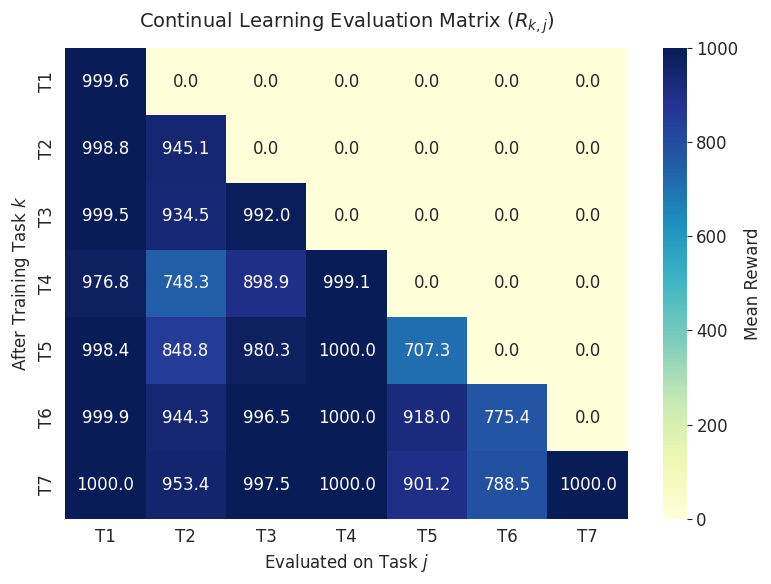

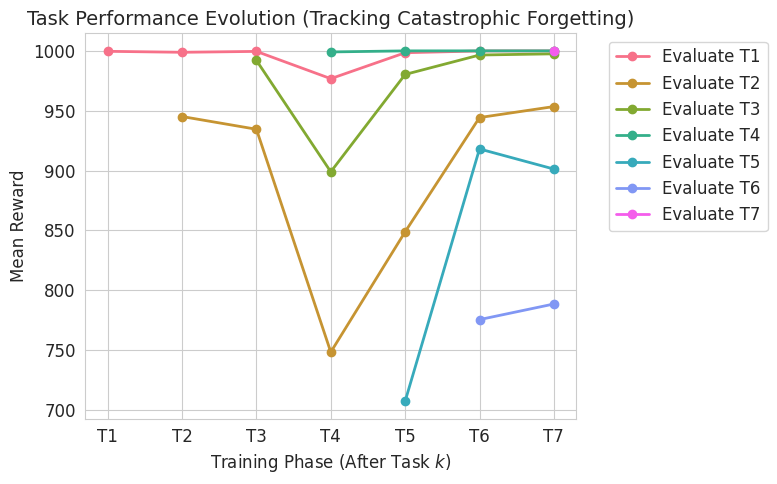

Charts successfully saved to 'charts' directory as high-res PDFs.


In [ ]:
# Save IEEE-formatted charts.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def generate_ieee_charts(csv_path="checkpoints/metrics.csv", output_dir="charts"):
    """
    Reads the R_matrix from the saved CSV and generates standard 
    Continual Learning evaluation plots.
    """
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found. Please run training first.")
        return

    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    
    # Set IEEE paper styling (Times New Roman, clear gridlines)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['font.size'] = 12
    sns.set_style("whitegrid")
    
    tasks = [f"T{i+1}" for i in range(len(df.columns))]

    # 1. Heatmap (R_matrix)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Reward'}, 
                xticklabels=tasks, yticklabels=tasks)
    plt.title('Continual Learning Evaluation Matrix ($R_{k,j}$)', fontsize=14, pad=15)
    plt.xlabel('Evaluated on Task $j$', fontsize=12)
    plt.ylabel('After Training Task $k$', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "evaluation_matrix_heatmap.pdf"), dpi=300)
    plt.show()

    # 2. Performance Degradation (Forgetting) Over Time
    plt.figure(figsize=(8, 5))
    colors = sns.color_palette("husl", len(tasks))
    
    for i, col in enumerate(df.columns):
        # Only plot data from when the task was first encountered onwards
        y_data = df[col].iloc[i:]
        x_data = range(i+1, len(df)+1)
        
        plt.plot(x_data, y_data, marker='o', linewidth=2, label=f'Evaluate {col}', color=colors[i])
        
    plt.title('Task Performance Evolution (Tracking Catastrophic Forgetting)', fontsize=14)
    plt.xlabel('Training Phase (After Task $k$)', fontsize=12)
    plt.ylabel('Mean Reward', fontsize=12)
    plt.xticks(range(1, len(tasks)+1), tasks)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "performance_evolution.pdf"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Charts successfully saved to '{output_dir}' directory as high-res PDFs.")

# Execute the chart generation
generate_ieee_charts()

In [ ]:
print("IEEE charts generated successfully.")